<a href="https://colab.research.google.com/github/AGENT1736/Iris-dataset-exploration/blob/main/iris_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [3]:
iris = load_iris(as_frame=True)

In [4]:
df = iris.frame

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [7]:
print(enumerate(iris.target_names))

In [8]:
target_names = dict(enumerate(iris.target_names))

In [9]:
print(target_names)

{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [10]:
df["species"] = df["target"].map(target_names)

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
print("\n shape:", df.shape)
print("-"*50)
print("\n info: \n",df.info)
print("-"*50)
print("\n describe(numeric): \n",df.describe)


 shape: (150, 6)
--------------------------------------------------

 info: 
 <bound method DataFrame.info of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3  

In [13]:
feature_cols = iris.feature_names
x = df[feature_cols]
y = df["target"]

In [14]:
x = x.to_numpy()
y = y.to_numpy()

In [15]:
#numpy stats col wise
col_means = x.mean(axis=0)
col_stds = x.std(axis=0, ddof=0)
print("means:", col_means)
print("stds:", col_stds)

means: [5.84333333 3.05733333 3.758      1.19933333]
stds: [0.82530129 0.43441097 1.75940407 0.75969263]


In [16]:
print("Missing values in the dataframe:")
print(df.isnull().sum())

Missing values in the dataframe:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [17]:
df.groupby("species")[feature_cols].mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


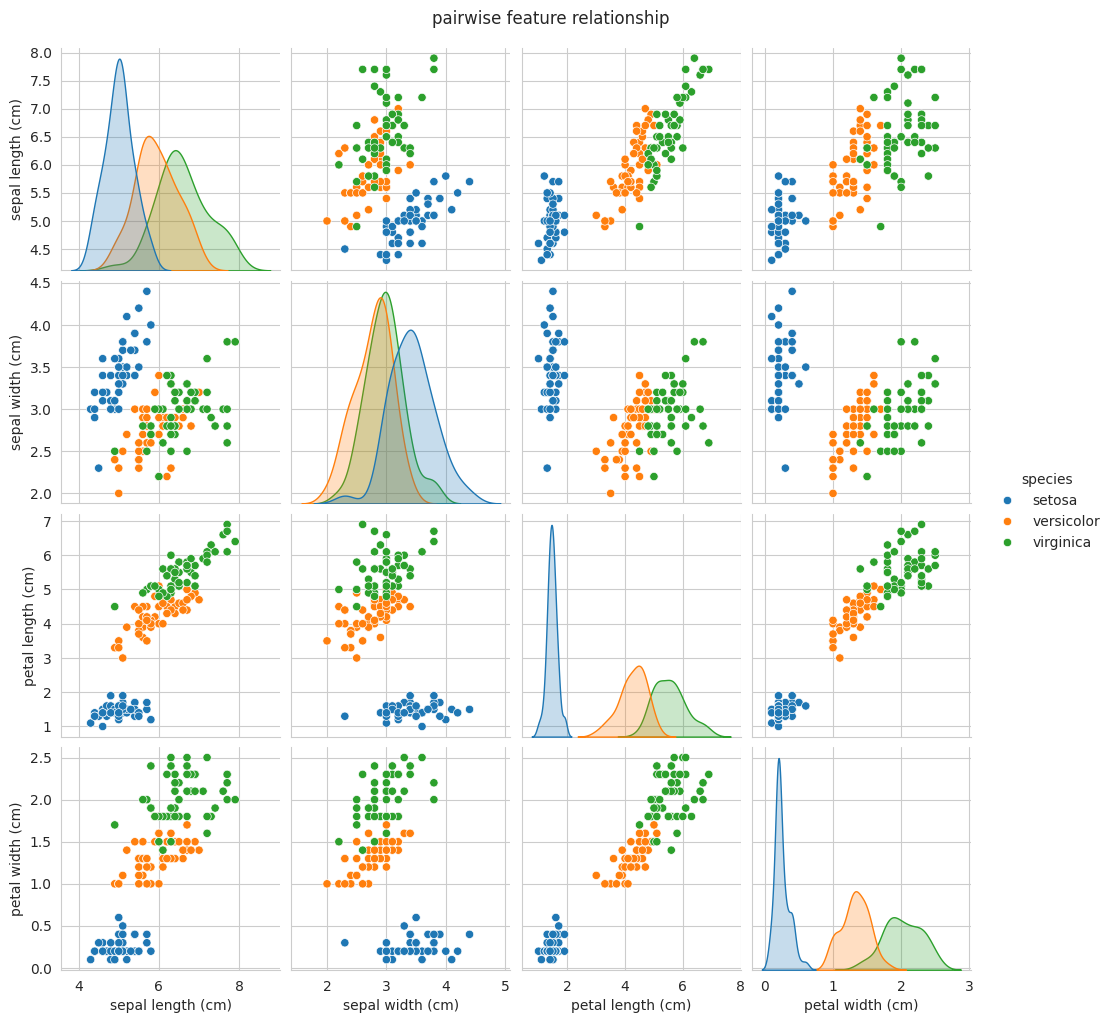

In [18]:
#pariplot with seaborn
sns.set_style("whitegrid")

sns.pairplot(df[feature_cols+["species"]],hue="species",diag_kind="kde")
plt.suptitle("pairwise feature relationship", y=1.02)
plt.show()

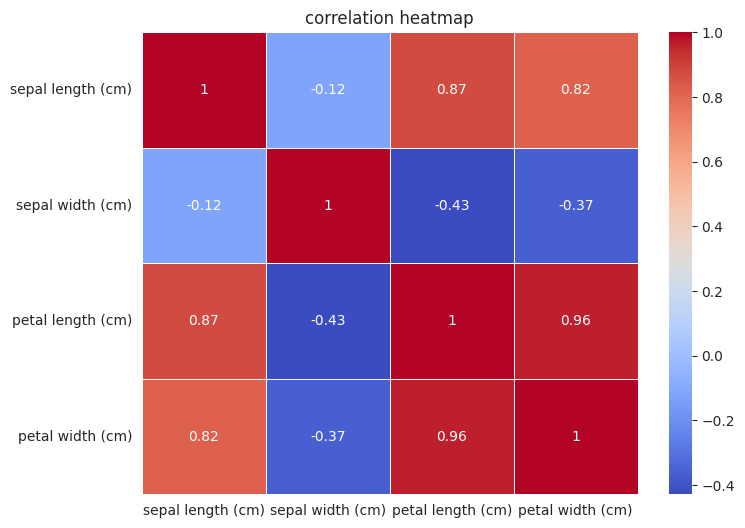

In [21]:
corr = df[feature_cols].corr(numeric_only = True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm",linewidths=0.5)
plt.title("correlation heatmap")
plt.show()

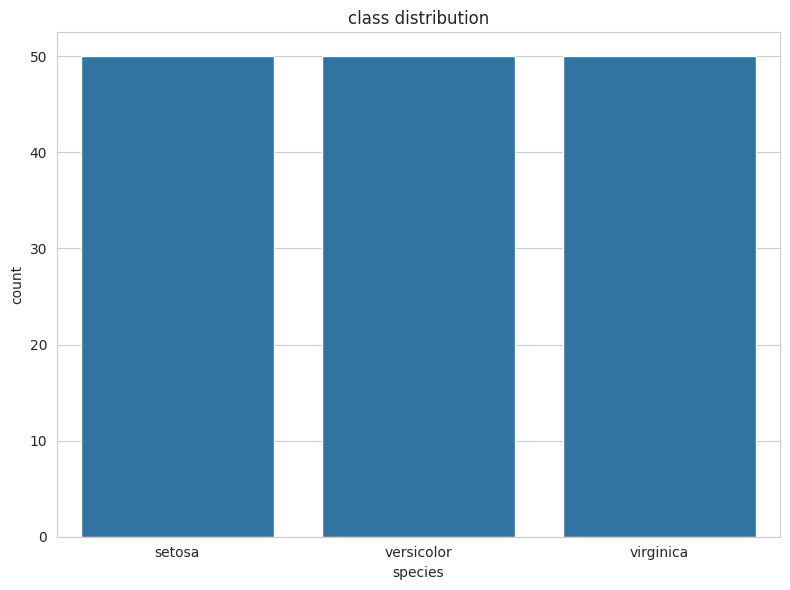

In [22]:
plt.figure(figsize=(8,6))
sns.countplot(x="species",data=df)
plt.title("class distribution")
plt.xlabel("species")
plt.ylabel("count")
plt.tight_layout()
plt.show()

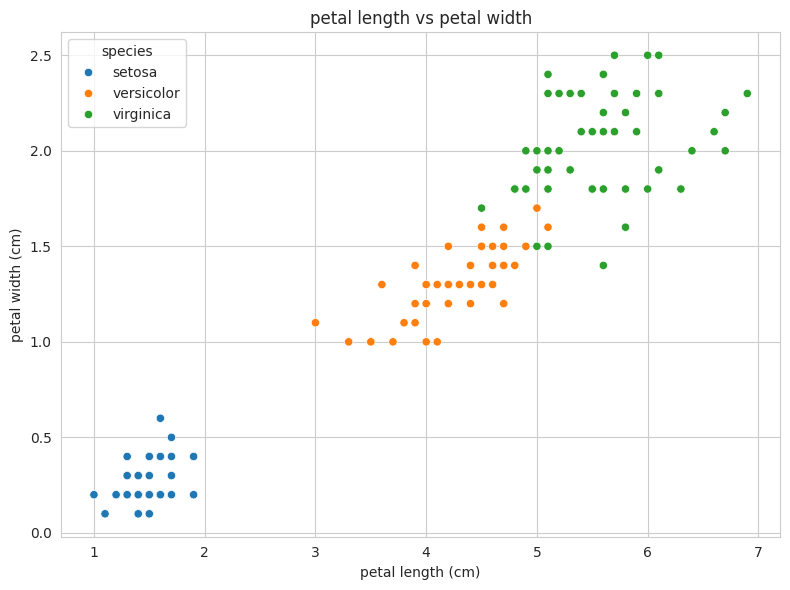

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
    )
plt.title("petal length vs petal width")
plt.tight_layout()
plt.show()